# 开集识别：白色区域一定识别对了吗？

仅已知类监督训练；阈值只由已知验证集校准。背景黑色，未知/拒识白色，错误图必须与预测图一起看。

默认 demo 加载预先训练权重，核心算法在下方逐步演示。旧实验数字不作为本次结果。

In [1]:
from pathlib import Path
import sys
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'src/hsi_learning').is_dir() and (p / 'dataset').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from inside the HSI-Learning repository')
sys.path.insert(0, str(ROOT / 'src'))
import numpy as np
import torch
# Notebook kernels must explicitly use inline rendering even when the CLI
# parent uses MPLBACKEND=Agg for non-interactive training scripts.
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')
import matplotlib.pyplot as plt
from hsi_learning.data import load_hsi_dataset
from hsi_learning.teaching_runs import load_bundle, encode_ids
from hsi_learning.teaching import patches_at, prototype_logits, prototypes, grad_cam
from hsi_learning.teaching_plots import style, maps
style()
torch.set_num_threads(2)
print('Python:', sys.executable)
print('Repository:', ROOT)


Python: D:\DevSpace\HSI-Learning\.venv\Scripts\python.exe
Repository: D:\DevSpace\HSI-Learning


In [2]:
# Classroom mode NEVER silently starts training.
MODE = 'demo'  # 'train' explicitly starts the full preparation queue below
BUNDLE_ROOT = ROOT / 'results/teaching_ready'
if MODE == 'train':
    import subprocess
    subprocess.run([sys.executable, str(ROOT/'scripts/prepare_teaching_artifacts.py')], check=True)
elif MODE != 'demo':
    raise ValueError('MODE must be demo or train')


In [3]:
model,cube,gt,names,split,cfg=load_bundle(BUNDLE_ROOT/'openset')
print('Known:',cfg['classes'],'Unknown:',cfg['unknown_classes'])
print('Threshold calibration:',cfg['acceptance'],'known validation acceptance target')
print('Preprocessing:',cfg['preprocessing'])


Known: [2, 3, 4, 5, 6, 8, 10, 11, 12, 13, 14, 15] Unknown: [1, 7, 9, 16]
Threshold calibration: 0.95 known validation acceptance target
Preprocessing: PCA+scaler fit known training centers only


## 两种 unknown score
MSP分数=1−最大softmax；距离分数=到最近训练类原型距离。均为越大越未知。特征与标签必须同序。

In [4]:
from hsi_learning.teaching import unknown_scores,calibrate_threshold,rejection_predictions
train_ids=split['train_ids']; classes=cfg['classes']
train_emb=encode_ids(model,cube,train_ids,classifier=True)
y=torch.tensor([classes.index(int(c)) for c in gt.ravel()[train_ids]])
centers=prototypes(train_emb,y,range(len(classes)))
print('Prototypes:',tuple(centers.shape))
# Shuffle feature-label PAIRS together: the result must not change.
order=torch.randperm(len(y))
torch.testing.assert_close(centers,prototypes(train_emb[order],y[order],range(len(classes))),atol=1e-5,rtol=1e-5)


Prototypes: (12, 128)


In [5]:
val_emb=encode_ids(model,cube,split['val_ids'],classifier=True)
with torch.no_grad(): val_scores=unknown_scores(model.head(val_emb),val_emb,centers)
thresholds={key:calibrate_threshold(score.numpy(),cfg['acceptance'])
            for key,score in zip(['msp','distance'],val_scores)}
print('Validation-only thresholds:',thresholds)
for key in thresholds: assert np.isclose(thresholds[key],cfg['thresholds'][key],rtol=1e-5)


Validation-only thresholds: {'msp': 0.2456449270248413, 'distance': 5.557234764099121}


{
  "known_accuracy": 0.9585093167701864,
  "best_val": 0.9751490950584412,
  "msp": {
    "auroc": 0.8494287042880393,
    "known_false_rejection": 0.06409937888198758,
    "known_correct_acceptance": 0.9197515527950311,
    "unknown_recall": 0.32620320855614976,
    "unknown_miss": 0.6737967914438503
  },
  "distance": {
    "auroc": 0.850811439200186,
    "known_false_rejection": 0.05453416149068323,
    "known_correct_acceptance": 0.9207453416149068,
    "unknown_recall": 0.5401069518716578,
    "unknown_miss": 0.45989304812834225
  }
}


msp AUROC: 0.8494287042880393
distance AUROC: 0.850811439200186


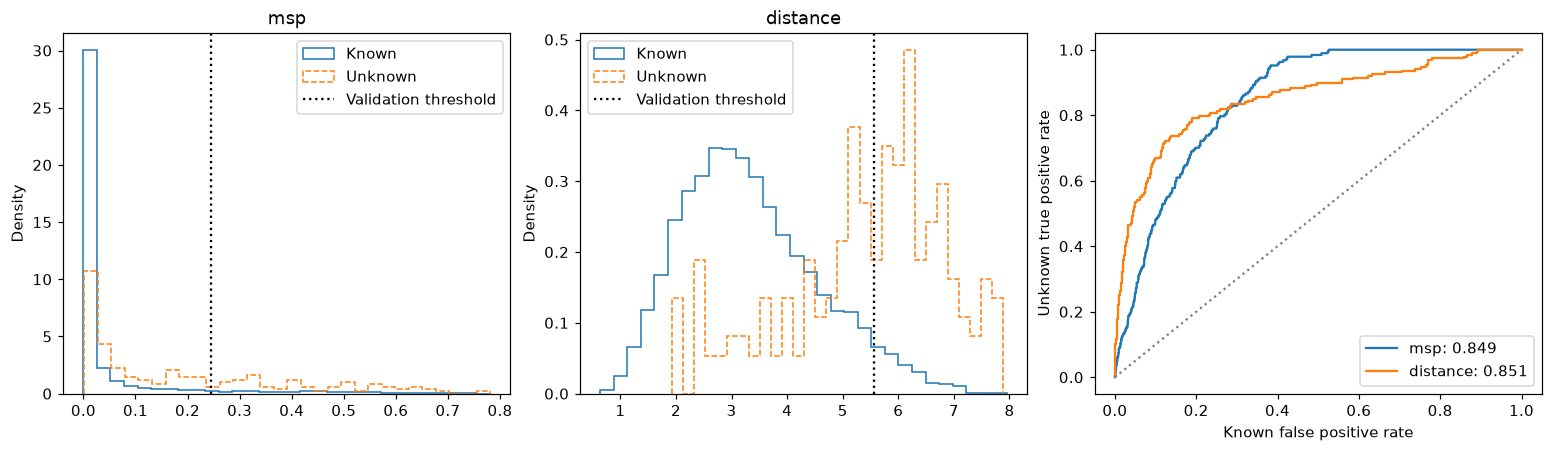

In [6]:
import json
from sklearn.metrics import roc_auc_score,roc_curve
recorded=json.loads((BUNDLE_ROOT/'openset/metrics.json').read_text())
print(json.dumps(recorded,indent=2))
test_ids=split['test_ids']; true=gt.ravel()[test_ids]
known=np.isin(true,classes)
te=encode_ids(model,cube,test_ids,classifier=True)
with torch.no_grad():
    logits=model.head(te); scores=unknown_scores(logits,te,centers)
fig,axes=plt.subplots(1,3,figsize=(14,4),layout='constrained')
for i,(key,score) in enumerate(zip(['msp','distance'],scores)):
    score=score.numpy(); auc=roc_auc_score(~known,score)
    print(key,'AUROC:',auc)
    axes[i].hist(score[known],bins=30,density=True,histtype='step',label='Known')
    axes[i].hist(score[~known],bins=30,density=True,histtype='step',linestyle='--',label='Unknown')
    axes[i].axvline(thresholds[key],color='black',linestyle=':',label='Validation threshold')
    axes[i].set_title(key); axes[i].set_ylabel('Density'); axes[i].legend()
    fpr,tpr,_=roc_curve(~known,score); axes[2].plot(fpr,tpr,label=f'{key}: {auc:.3f}')
axes[2].plot([0,1],[0,1],':',color='gray'); axes[2].set_xlabel('Known false positive rate')
axes[2].set_ylabel('Unknown true positive rate'); axes[2].legend(); plt.show()


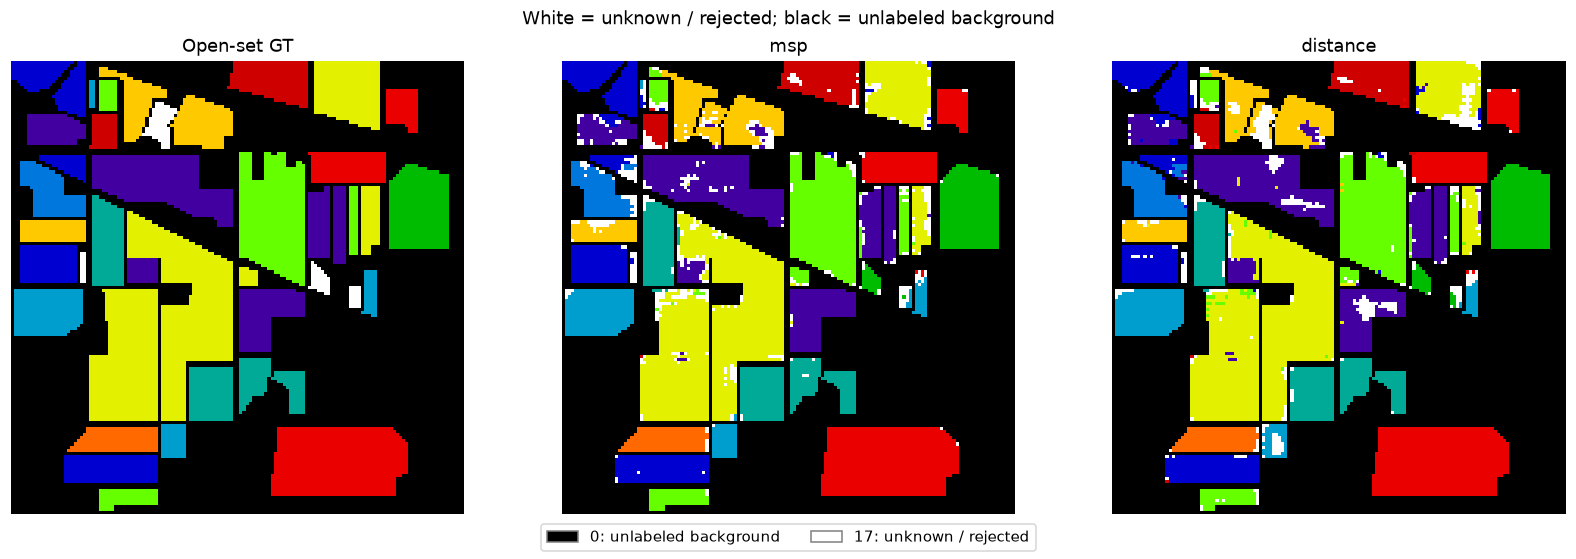

Class IDs: {1: 'Alfalfa', 2: 'Corn-notill', 3: 'Corn-mintill', 4: 'Corn', 5: 'Grass-pasture', 6: 'Grass-trees', 7: 'Grass-pasture-mowed', 8: 'Hay-windrowed', 9: 'Oats', 10: 'Soybean-notill', 11: 'Soybean-mintill', 12: 'Soybean-clean', 13: 'Wheat', 14: 'Woods', 15: 'Buildings-Grass-Trees-Drives', 16: 'Stone-Steel-Towers'}


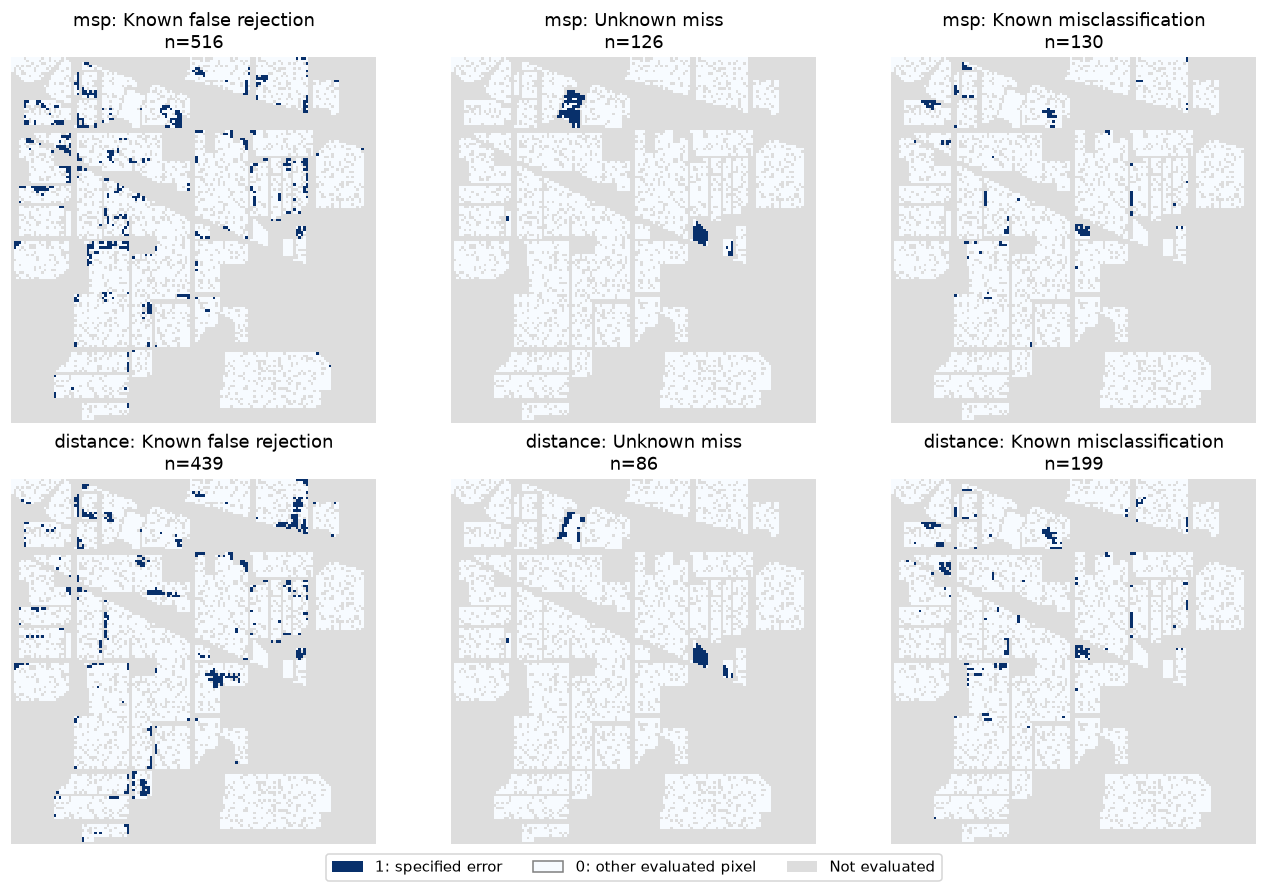

White pixels may be correct rejections OR known-class false rejections.


In [7]:
from hsi_learning.teaching_plots import openset_maps,error_panels
panels,outputs=openset_maps(model,cube,gt,split,cfg)
maps(gt,panels,names,'White = unknown / rejected; black = unlabeled background')
error_panels(gt,outputs,split,cfg)
print('White pixels may be correct rejections OR known-class false rejections.')


## 练习
把已知接受率目标从.95改成.90，只使用验证分数重新校准；解释误拒与漏检的变化。AUROC是排序指标，不是固定阈值下的分类精度。

本例是同场景中心监督设定，patch可能包含未知地物的无标签观测；不宣称空间外推。OpenMax为概念延伸，未伪装成此处的距离法。